
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Dependencies

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils
logger = Logger()

success(logger, "Dependencies loaded")


[success] Dependencies loaded


## Helpers

In [2]:
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")


[success] Helper loaded


# Unit Tests (Toy Datasets)
Kiểm thử tự động trên 5 CSDL thử nghiệm (Toy datasets) nhằm tái tạo đúng kết quả, đối chiếu với SPMF theo yêu cầu đồ án.
## Giới thiệu các tập dữ liệu kiểm thử (Toy Datasets)

Để đảm bảo tính đúng đắn của thuật toán FP-Growth trước khi chạy trên dữ liệu lớn, chúng ta sử dụng 5 tập dữ liệu nhỏ (Toy Datasets) với các kịch bản khác nhau. Dưới đây là mô tả chi tiết:

| Tập dữ liệu | Số giao dịch | Nội dung | Mục tiêu kiểm thử |
| :--- | :--- | :--- | :--- |
| **test1.txt** | 7 | {1,2,3,4,5}, {1,2,3,4,5}, {1,2,3,4}, {1,2,3}, {1,2,3}, {1,2}, {1} | Kiểm tra khả năng xử lý các itemset lồng nhau và giảm dần độ phổ biến. |
| **test2.txt** | 6 | {1,2,4,5}, {2,3,5}, {1,2,4,5}, {1,2,3,5}, {1,2,3,4,5}, {2,3,4} | Kiểm tra dữ liệu có mật độ trung bình với các item xuất hiện rải rác. |
| **test3.txt** | 7 | {1,2,3,4}, {2,3,4}, {2,3}, {1,2,4}, {1,2,3,4}, {2,4}, {1,3,4} | Kiểm tra các tổ hợp phổ biến của một nhóm item cụ thể {2, 3, 4}. |
| **test4.txt** | 4 | {2,3,5}, {1,2,3,5}, {2,5}, {1,2,3,5} | Kiểm tra trường hợp tập dữ liệu cực nhỏ (Edge case). |
| **test5.txt** | 5 | {1,2}, {2,3}, {3,4}, {4,5}, {1,5} | Kiểm tra dữ liệu dạng chuỗi (Chain), nơi mỗi item có liên kết hạn chế. |

> **Lưu ý**: Các tập dữ liệu này sẽ được đối chiếu kết quả trực tiếp với thư viện SPMF để xác nhận tính chính xác của mã nguồn Julia.

### **Test 1**

<!-- #### **Giới thiệu**
Dataset gồm 7 transactions và 5 items phân biệt, được mã hóa bằng các số nguyên từ 1 đến 5 theo đúng định dạng đầu vào chuẩn của SPMF (space-separated transaction format). Mỗi dòng trong Dataset biểu diễn một transaction, trong đó những item xuất hiện đồng thời trong cùng một transaction.

#### Tập dữ liệu

```text
1 2 3 4 5
1 2 3 4 5
1 2 3 4
1 2 3
1 2 3
1 2
1
```

#### Đặc điểm

Tập dữ liệu được thiết kế theo cấu trúc giảm dần số lượng item trong mỗi giao dịch. Điều này tạo ra một đặc tính quan trọng đối với FP-Growth:

* Các item có độ hỗ trợ cao xuất hiện lặp lại nhiều lần.
* Sau khi sắp xếp theo tần suất giảm dần, các giao dịch có xu hướng chia sẻ cùng tiền tố (common prefix).
* FP-tree sinh ra có mức độ nén cao do nhiều giao dịch đi qua cùng một nhánh. -->

In [3]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test1.txt 
               --minsup 0.4
               --output results/result1.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_3034.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test1.txt
[success] Successfully loaded 6 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 19 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result1.txt


Process(`julia --project main.jl --input data/toy/test1.txt --minsup 0.4 --output results/result1.txt`, ProcessExited(0))

### **Test 2**

<!-- Dữ liệu được lưu theo định dạng chuẩn của SPMF, trong đó mỗi dòng biểu diễn một giao dịch và các mục được phân tách bằng khoảng trắng:

```txt
1 2 4 5
2 3 5
1 2 4 5
1 2 3 5
1 2 3 4 5
2 3 4
````

Để tối ưu hóa hiệu năng xử lý và đảm bảo tính tương thích với thư viện SPMF, các mục ban đầu được ánh xạ sang dạng số nguyên. Bảng ánh xạ được sử dụng như sau:

| Item | Item ID |
| ------- | ----- |
| A       | 1     |
| B       | 2     |
| C       | 3     |
| D       | 4     |
| E       | 5     |

Sau khi ánh xạ, cơ sở dữ liệu giao dịch có thể được biểu diễn lại dưới dạng ký hiệu như sau:

| Transaction ID | Itemset           |
| -------------- | ----------------- |
| $T_1$          | ${A, B, D, E}$    |
| $T_2$          | ${B, C, E}$       |
| $T_3$          | ${A, B, D, E}$    |
| $T_4$          | ${A, B, C, E}$    |
| $T_5$          | ${A, B, C, D, E}$ |
| $T_6$          | ${B, C, D}$       |

Tập dữ liệu này có đặc điểm là:

* tồn tại nhiều giao dịch có tiền tố chung,
* xuất hiện nhiều nhánh khác nhau trong quá trình xây dựng FP-tree,
* đồng thời có sự giao thoa giữa các mục phổ biến.

Do đó, FP-tree tạo ra sẽ có cấu trúc phân nhánh thay vì chỉ gồm một đường đi duy nhất. Điều này cho phép minh họa đầy đủ các bước quan trọng của thuật toán FP-Growth, bao gồm:

* đếm độ hỗ trợ của từng mục,
* sắp xếp giao dịch theo tần suất giảm dần,
* xây dựng FP-tree,
* tạo conditional pattern base,
* xây dựng conditional FP-tree,
* và khai phá đệ quy các frequent itemset. -->


In [4]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test2.txt 
               --minsup 0.4
               --output results/result2.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_4F55.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test2.txt
[success] Successfully loaded 7 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 15 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result2.txt


Process(`julia --project main.jl --input data/toy/test2.txt --minsup 0.4 --output results/result2.txt`, ProcessExited(0))

### **Test 3**

In [5]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test3.txt 
               --minsup 0.4
               --output results/result3.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_6DE9.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test3.txt
[success] Successfully loaded 6 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 11 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result3.txt


Process(`julia --project main.jl --input data/toy/test3.txt --minsup 0.4 --output results/result3.txt`, ProcessExited(0))

### **Test 4**

In [6]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test4.txt 
               --minsup 0.4
               --output results/result4.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_8C10.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test4.txt
[success] Successfully loaded 5 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 2)
[process] Executing FP-Growth...
[success] Mined 15 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result4.txt


Process(`julia --project main.jl --input data/toy/test4.txt --minsup 0.4 --output results/result4.txt`, ProcessExited(0))

### **Test 5**

In [7]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test5.txt 
               --minsup 0.4
               --output results/result5.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_ABBD.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test5.txt
[success] Successfully loaded 5 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 2)
[process] Executing FP-Growth...
[success] Mined 5 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result5.txt


Process(`julia --project main.jl --input data/toy/test5.txt --minsup 0.4 --output results/result5.txt`, ProcessExited(0))

### Config

In [8]:
Random.seed!(42)
CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "Minimum Support" => 0.4,
    
    # File dành riêng cho Optimization Benchmark (Dữ liệu lớn)
    "dataset_path" => "../data/benchmark/connect-4.dat", 
    
    # Danh sách file dành cho Unit Test (Dữ liệu nhỏ)
    "datasets_path" => [
        "../data/toy/test1.txt",
        "../data/toy/test2.txt",
        "../data/toy/test3.txt",
        "../data/toy/test4.txt",
        "../data/toy/test5.txt"
    ],
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")


[success] Config loaded


In [9]:
accuracy = run_unitTest(CONFIG, logger)



__________________________________________________
[phase]  UNIT TESTING
__________________________________________________
[info] Executing tests on 5 datasets with MinSup=40.0% and Evaluate correctness in results with SPMF
[process] Test 1/5: test1.txt
[success] ✓ Test 1 Passed (19 itemsets)
[process] Test 2/5: test2.txt
[success] ✓ Test 2 Passed (15 itemsets)
[process] Test 3/5: test3.txt
[success] ✓ Test 3 Passed (11 itemsets)
[process] Test 4/5: test4.txt
[success] ✓ Test 4 Passed (15 itemsets)
[process] Test 5/5: test5.txt
[success] ✓ Test 5 Passed (5 itemsets)

__________________________________________________
[phase]  UNIT TEST RESULTS
__________________________________________________
[success] Accuracy Rate: 100.0% (Passed 5/5)


100.0

## Optimization Evaluation (Basic vs Optimized)
So sánh hiệu năng giữa phiên bản FP-Growth cơ bản và phiên bản đã được tối ưu hóa. Do đó, nhằm để đánh giá hiệu năng tối ưu hóa, chúng ta sử dụng tập dữ liệu **Mushroom** - một benchmark chuẩn trong khai phá dữ liệu.

### Giới thiệu
- **Nguồn**: UCI Machine Learning Repository.
- **Số lượng giao dịch**: 8,124.
- **Số lượng thuộc tính**: 22 thuộc tính phân loại (categorical attributes).
- **Số lượng items (sau mã hóa)**: Khoảng 119 items.
- **Độ dài trung bình giao dịch**: 23 items.

### Đặc điểm thuộc tính
Dữ liệu mô tả các đặc tính vật lý của các loài nấm (thuộc họ Agaricus và Lepiota) như hình dạng mũ nấm, bề mặt, màu sắc, mùi vị, và môi trường sống. Mỗi bản ghi được gán nhãn là "ăn được" (edible) hoặc "có độc" (poisonous).

### Tính chất cho khai phá dữ liệu
- **Dense Dataset**: Mushroom có đặc tính tương quan rất cao giữa các thuộc tính. Khi chạy với ngưỡng support thấp, số lượng tập phổ biến sinh ra sẽ rất lớn.
- **Hierarchical structure**: Các thuộc tính thường xuất hiện cùng nhau theo các mẫu cố định, tạo ra nhiều single paths trong cây FP-Tree.

### Lý do lựa chọn cho bài toán tối ưu hóa
- **Thách thức về đệ quy**: Do tính chất dày, FP-Growth cơ bản sẽ phải thực hiện rất nhiều bước đệ quy sâu. Đây là cơ hội tốt nhất để kiểm chứng hiệu quả của kỹ thuật **Single Path Pruning** và **BitArray Filtering**.
- **Tính chuẩn hóa**: Việc khớp kết quả với SPMF trên tập Mushroom là một minh chứng mạnh mẽ cho tính đúng đắn của thuật toán tối ưu trên các cấu trúc dữ liệu phức tạp.

In [13]:
# import Pkg
# deps = Pkg.project().dependencies
# for pkg in ["DataFrames", "CSV", "Plots"]
#     if !haskey(deps, pkg)
#         Pkg.add(pkg)
#     end
# end

# using CSV
# using DataFrames
# using Random
# using Plots
# using Plots.PlotMeasures
# using ProgressMeter
# using Statistics
# gr()

# include("../src/FPGrowth.jl")
# using .FPGrowth
# include("../src/logger.jl")
# include("../src/utils.jl")
# using .Utils
# logger = Logger()

# success(logger, "Dependencies loaded")
# include("../src/eval.jl")
# using .Utils
# success(logger, "Helper loaded")

# Random.seed!(42)


In [11]:

CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "Minimum Support" => 0.8,
    
    # File dành riêng cho Optimization Benchmark (Dữ liệu lớn)
    "dataset_path" => "E:\\Lab02-Data-Mining\\data\\benchmark\\mushroom.dat\\mushroom.dat", 
    
    # Danh sách file dành cho Unit Test (Dữ liệu nhỏ)
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")



[success] Config loaded



__________________________________________________
[phase]  OPTIMIZATION COMPARISON
__________________________________________________
[info] Comparing Basic vs Optimized version on: mushroom.dat
[info] Threshold MinSup=80.0%
[process] Running Basic FPGrowth...
[process] Running Optimized FPGrowth (Single Path Pruning + BitArray)...
[success] ✓ Internal Consistency: Basic and Optimized versions match (23 itemsets)
[process] Verifying results against SPMF Java baseline...
[success] ✓ SPMF Verified: Julia results are identical to SPMF Java.
   [metric] Basic Time: 0.0044s
   [metric] Optimized Time: 0.0034s
[success] Improvement: 22.57% faster

__________________________________________________
[phase]  visualize
__________________________________________________


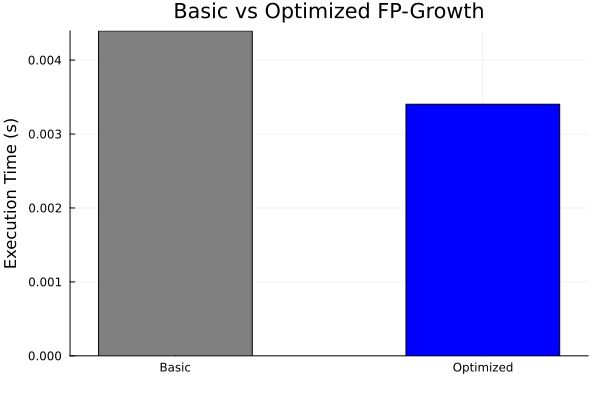

In [12]:
opt_results = eval_optimization(CONFIG, logger)
vis_optimization(opt_results, logger)
